# 02 – Data Cleaning and Preprocessing

## Purpose

This notebook focuses on preparing the network intrusion dataset for analysis and modeling. The goal is to improve data quality by handling missing values, duplicate records, and inconsistencies.

## Objectives

- Clean the dataset by removing duplicates  
- Handle missing values appropriately  
- Standardize column names  
- Prepare data for further analysis and modeling  

## Dataset

The dataset used is the CIC-style network intrusion dataset containing network flow records with labeled traffic (benign and attack types).

This step supports Phase 2 of the project and ensures the data is reliable for downstream tasks such as feature engineering and machine learning.

## Step 1 - Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/Wednesday-workingHours.pcap_ISCX.csv", low_memory=False)

df.columns = df.columns.str.strip()

df.shape

(692703, 79)

### Observation:

- The dataset was successfully loaded from the raw data directory. Column names were cleaned by removing leading and trailing spaces to ensure consistency during preprocessing.
- The dataset contains 692,703 records and 79 features representing network traffic flows. This confirms that the dataset is large and suitable for further analysis and machine learning tasks.

## Step 2 - Remove Duplicates

In [2]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 81909
Shape after removing duplicates: (610794, 79)


### Observation:

- A total of 81,909 duplicate records were identified in the dataset. These duplicates were removed to improve data quality and prevent bias during analysis and model training.
- After removing duplicates, the dataset size was reduced to 610,794 records while retaining all 79 features.

## Step 3 - Handle Missing Values

In [3]:
missing = df.isnull().sum().sum()
print("Total missing values:", missing)

df["Flow Bytes/s"] = df["Flow Bytes/s"].fillna(0)

print("Missing after handling:", df.isnull().sum().sum())

Total missing values: 61
Missing after handling: 0


### Observation:

- The dataset contained a small number of missing values (61) in the feature "Flow Bytes/s".
- These missing values were handled by replacing them with 0, assuming no flow activity in those cases.
- After handling missing values, the dataset contains no null values, ensuring it is clean and ready for further preprocessing and analysis.

In [4]:
df.sample(10)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
372019,54892,261,3,0,31,0,31,0,10.333333,17.897858,...,32,0.0,0.000,0,0,0.0,0.000,0,0,BENIGN
595852,34206,64,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.000,0,0,0.0,0.000,0,0,BENIGN
351807,53,474,1,1,56,116,56,56,56.000000,0.000000,...,32,0.0,0.000,0,0,0.0,0.000,0,0,BENIGN
246963,53,49863,1,1,94,110,94,94,94.000000,0.000000,...,20,0.0,0.000,0,0,0.0,0.000,0,0,BENIGN
610805,53,248,2,2,76,108,38,38,38.000000,0.000000,...,20,0.0,0.000,0,0,0.0,0.000,0,0,BENIGN
318325,53,2245044,2,2,93,282,51,42,46.500000,6.363961,...,20,0.0,0.000,0,0,0.0,0.000,0,0,BENIGN
618316,443,1266725,3,3,0,18,0,0,0.000000,0.000000,...,28,0.0,0.000,0,0,0.0,0.000,0,0,BENIGN
423302,53,167,2,2,64,248,32,32,32.000000,0.000000,...,20,0.0,0.000,0,0,0.0,0.000,0,0,BENIGN
471721,443,5529397,9,10,625,3855,321,0,69.444444,115.757409,...,32,0.0,0.000,0,0,0.0,0.000,0,0,BENIGN
372038,443,16981105,12,8,1264,3660,629,0,105.333333,195.803395,...,20,719699.0,873609.215,1337434,101964,7770843.5,3159984.545,10000000,5536397,BENIGN


## Step 4 - Check data types and infinities before scaling

In [6]:
# Check data types
print(df.dtypes.value_counts())

# Check for infinity values in numeric columns
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])
print("Infinity values:", np.isinf(numeric_df).sum().sum())

int64      54
float64    24
object      1
Name: count, dtype: int64
Infinity values: 543


## Step 5 - Replace infinity values with 0

In [7]:
import numpy as np

df = df.replace([np.inf, -np.inf], 0)

numeric_df = df.select_dtypes(include=[np.number])
print("Infinity values after handling:", np.isinf(numeric_df).sum().sum())

Infinity values after handling: 0


### Handling Infinity Values

- Before feature scaling, infinity values were identified in the numeric features. These values cause errors during preprocessing and model training.
- All positive and negative infinity values were replaced with 0 to ensure the dataset is numerically stable and suitable for scaling.

## Step 6 - Feature Scaling

In [8]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop("Label", axis=1)
y = df["Label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed")

Feature scaling completed


### Feature Scaling

- Feature scaling was applied to the dataset using StandardScaler. This technique standardizes numerical features by transforming them to have a mean of 0 and a standard deviation of 1.
- Before scaling, infinity values were handled to prevent errors during transformation. Scaling ensures that all features contribute equally to machine learning models and improves model performance.

## Step 7 - Encode the Target Variable

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Encoding completed")

Encoding completed


### Target Variable Encoding

- The target variable "Label" contains categorical values representing different types of network traffic (benign and attack types).
- These labels were converted into numerical format using LabelEncoder to make them suitable for machine learning models.

## Step 8 - Save Cleaned Dataset

In [10]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)
print("Cleaned dataset saved")

Cleaned dataset saved


### Saving Cleaned Dataset

- The cleaned dataset was saved to the processed data directory. This ensures that all preprocessing steps are preserved and can be reused for further analysis, feature engineering, and model development without repeating the cleaning process.

## Step 8.5 - Reload cleaned dataset

In [11]:
df = pd.read_csv("../data/processed/cleaned_data.csv")
df.shape

(610794, 79)

## Step 9 - Feature Engineering

In [14]:
# Create a new feature representing total packet volume in a flow
# This combines forward and backward packets to capture overall traffic size
df["Total Packets"] = df["Total Fwd Packets"] + df["Total Backward Packets"]

# Display a few rows to verify the new feature
df[["Total Fwd Packets", "Total Backward Packets", "Total Packets"]].head()

,Total Fwd Packets,Total Backward Packets,Total Packets
0,1,1,2
1,11,5,16
2,10,6,16
3,17,12,29
4,9,6,15


In [15]:
# Create a feature representing traffic intensity (packets per unit time)
# Adding 1 to Flow Duration avoids division by zero errors
df["Packets per Second"] = df["Total Packets"] / (df["Flow Duration"] + 1)

# Display a few rows to verify the new feature
df[["Total Packets", "Flow Duration", "Packets per Second"]].head()

,Total Packets,Flow Duration,Packets per Second
0,2,38308,0.000052
1,16,479,0.033333
2,16,1095,0.014599
3,29,15206,0.001907
4,15,1092,0.013724


### Feature Engineering

- Two new features were created to better represent network traffic behavior.
- The "Total Packets" feature combines forward and backward packet counts to capture the overall volume of traffic within each network flow. This helps in identifying flows with unusually high or low activity.
- The "Packets per Second" feature represents traffic intensity by relating packet volume to flow duration. High values may indicate rapid or bursty traffic patterns, which are often associated with network attacks such as Denial of Service (DoS).
- These engineered features provide more meaningful representations of network behavior and are expected to improve the performance of machine learning models.

## Step 10 - Correlation Analysis (important for modeling)

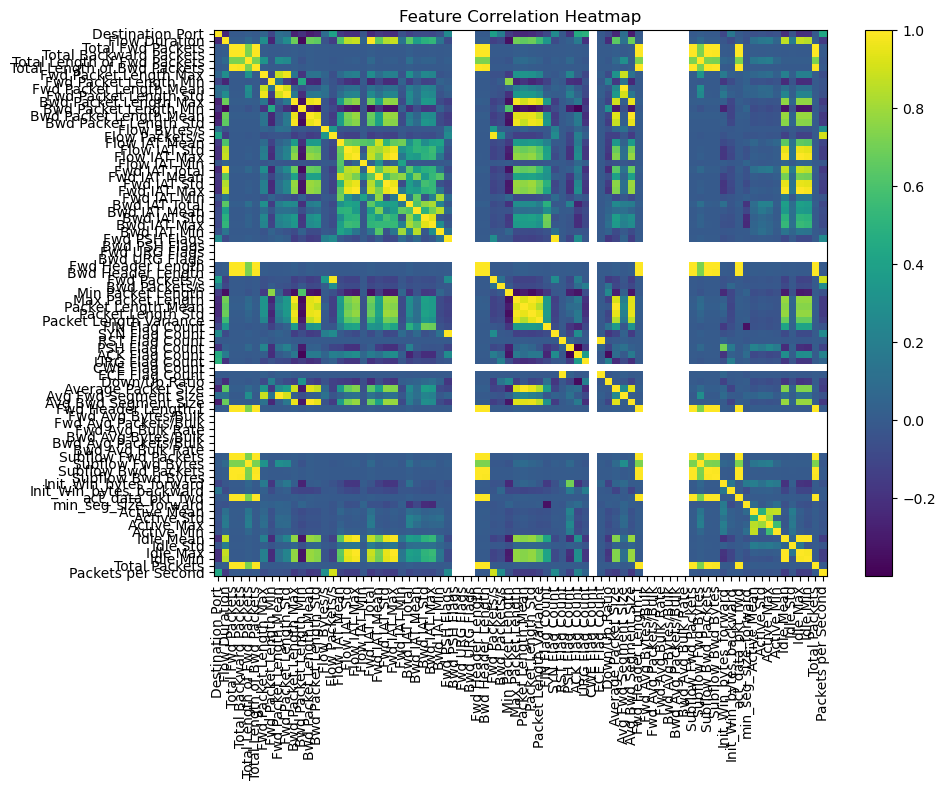

In [16]:
import matplotlib.pyplot as plt

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()

plt.title("Feature Correlation Heatmap")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.tight_layout()
plt.show()

In [19]:
import numpy as np

# Keep all numeric columns, including Label_encoded
numeric_df = df.select_dtypes(include=[np.number])

# Check that Label_encoded is included
print("Label_encoded" in numeric_df.columns)

True


In [20]:
# Compute correlation matrix using only numeric data
corr_matrix = numeric_df.corr()

# Get correlation with target variable
target_corr = corr_matrix["Label_encoded"].abs().sort_values(ascending=False)

# Show top 10 features excluding the label itself
top_features = target_corr[1:11]
print(top_features)

Fwd IAT Max               0.747350
Flow IAT Max              0.747040
Idle Max                  0.746524
Fwd IAT Std               0.738187
Bwd Packet Length Mean    0.735394
Avg Bwd Segment Size      0.735394
Idle Mean                 0.734738
Idle Min                  0.722642
Bwd Packet Length Max     0.716288
Packet Length Std         0.716060
Name: Label_encoded, dtype: float64


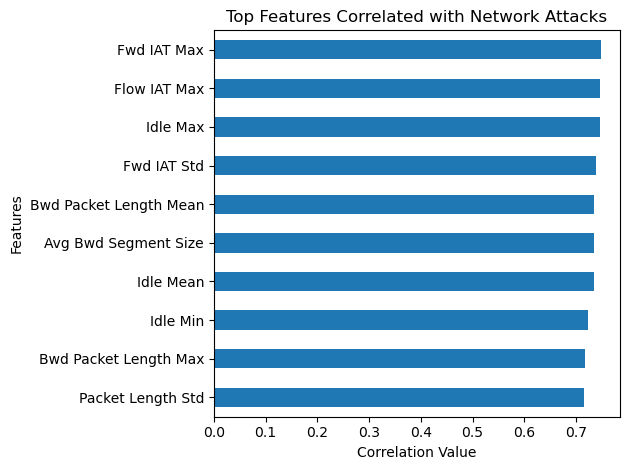

In [21]:
import matplotlib.pyplot as plt

# Plot top correlated features
plt.figure()
top_features.sort_values().plot(kind="barh")

plt.title("Top Features Correlated with Network Attacks")
plt.xlabel("Correlation Value")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

### Key Trends and Insights

- The analysis reveals that time-based features such as inter-arrival time (IAT) and idle durations have the strongest correlation with network traffic labels. This indicates that attack traffic behaves differently in terms of timing patterns compared to normal traffic.
- Features related to packet size and flow characteristics also show strong relationships with the target variable. This suggests that both traffic volume and timing play an important role in identifying malicious activity.
- Overall, the dataset demonstrates clear behavioral differences between benign and attack traffic, which can be leveraged for building effective machine learning models.

---

### Data Issues and Handling Strategy

- Several data quality issues were identified during the analysis.
- Duplicate records were found in the dataset and removed to prevent bias and redundancy in the model.
- Missing values were identified in the Flow Bytes per second feature and were handled by replacing them with zero, as they represent absence of measurable flow.
- Infinite values were detected in numeric columns and were handled by replacing them with finite values to ensure compatibility with scaling and modeling techniques.
- Categorical labels were encoded into numeric format to enable correlation analysis and machine learning processing.

---

### Conclusion

- The dataset has been successfully cleaned, transformed, and analyzed. Important features influencing network behavior have been identified, and data quality issues have been addressed.
- The dataset is now ready for machine learning model development and further advanced analysis.

## Database Integration

### 1. Knowledge Base Integration

- A separate knowledge base was created using Chroma to store network attack descriptions and troubleshooting steps.
- This component enables retrieval of relevant information for detected attacks, allowing the system to provide meaningful explanations and recommended actions.

### 2. Retrieval Testing

- The retrieval component was tested successfully using a sample query related to a DoS Hulk attack.
- The system was able to retrieve the relevant attack description and troubleshooting guidance from the Chroma knowledge base. This confirms that the retrieval layer is functioning correctly and can support the agent in providing context-aware explanations.

### 3. Prototype Agent Integration

- At this stage, the retrieval-based agent was tested using a simulated predicted attack label. This was done to validate the knowledge retrieval workflow before integrating the machine learning model in the next phase.
- The agent successfully retrieved an attack explanation and troubleshooting guidance from the Chroma knowledge base, demonstrating the feasibility of combining prediction outputs with contextual support.